<div style="padding:5px; border-radius:10px; background-color:#1a5276; color:white; text-align:center">
    <h3>🔍 Намерение покупателей совершать покупки онлайн</h3>
</div>

 **Разведочный анализ данных:** **https://stepik.org/course/177213**

### Описание данных:

* **Значение параметров Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration - ("Административная", "Административная продолжительность", "Информационная", "Информационная продолжительность", "Связанная с продуктом" и "Связанная с продуктом продолжительность")** - представляют количество различных типов страниц, посещенных посетителем в течение данного сеанса, и общее время, проведенное на каждой из этих категорий страниц. Значения этих полей выводятся из информации об URL-адресах посещаемых пользователем страниц и обновляются в режиме реального времени, когда пользователь выполняет какое-либо действие, например, переходит с одной страницы на другую. 
* **Значение параметров BounceRates, ExitRates и PageValues ("Показатель отказов", "Показатель посещаемости" и "Ценность страницы")** - представляют собой показатели, измеряемые "Google Analytics" для каждой страницы сайта электронной коммерции. 
* **Значение параметра BounceRates ("Показатель отказов")** - для веб-страницы относится к проценту посетителей, которые заходят на сайт с этой страницы, а затем покидают его ("показатель отказов"), не вызывая никаких других запросов к серверу аналитики в течение этого сеанса. 
* **Значение параметра ExitRates ("Показатель отказов")** - для конкретной веб-страницы рассчитывается как процент всех просмотров страницы, которые были последними в сеансе. 
* **Значение параметра PageValues ("Значение страницы")** - представляет собой среднее значение для веб-страницы, которую пользователь посетил перед завершением транзакции электронной коммерции. 
* **Значение параметра SpecialDay ("Особый день")** -  указывает на близость времени посещения сайта к определенному особому дню (например, Дню матери, Дню Святого Валентина), в который сеансы с большей вероятностью завершатся транзакцией. Значение этого параметра определяется с учетом динамики электронной коммерции, такой как промежуток времени между датой заказа и датой доставки. Например, для дня Святого Валентина это значение принимает ненулевое значение в период со 2 по 12 февраля, нулевое значение до и после этой даты, если только она не близка к другому особому дню, и его максимальное значение, равное 1, приходится на 8 февраля. 
* Набор данных также включает **OperatingSystems - операционную систему, Browser - браузер, Region - регион, TrafficType - тип трафика**, **VisitorType** - тип посетителя, возвращающегося или нового посетителя, логическое значение, указывающее, является ли дата посещения **Weekend** - выходным, и **Month** - месяц года. 
* **Revenue** - Доход

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

In [3]:
%matplotlib inline

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)
pd.set_option("display.width", 500)

In [5]:
import os
import sys

sys.path.insert(0, os.path.dirname(os.getcwd()))


In [6]:
from Datasets.DF import DATASET

df = pd.read_csv(DATASET)

In [7]:
print(f"\nНаименование колонок:")
for i, col in enumerate(df.columns, 1):
    print(f"    {i:2d}. '{col}'")


Наименование колонок:
     1. 'Administrative'
     2. 'Administrative_Duration'
     3. 'Informational'
     4. 'Informational_Duration'
     5. 'ProductRelated'
     6. 'ProductRelated_Duration'
     7. 'BounceRates'
     8. 'ExitRates'
     9. 'PageValues'
    10. 'SpecialDay'
    11. 'Month'
    12. 'OperatingSystems'
    13. 'Browser'
    14. 'Region'
    15. 'TrafficType'
    16. 'VisitorType'
    17. 'Weekend'
    18. 'Revenue'


In [48]:
print("\nТипы данных:")
for i, col in enumerate(df.columns, 1):
    print(f"    {i:2d}. '{col}': {df[col].dtype}")


Типы данных:
     1. 'Administrative': int64
     2. 'Administrative_Duration': float64
     3. 'Informational': int64
     4. 'Informational_Duration': float64
     5. 'ProductRelated': int64
     6. 'ProductRelated_Duration': float64
     7. 'BounceRates': float64
     8. 'ExitRates': float64
     9. 'PageValues': float64
    10. 'SpecialDay': float64
    11. 'Month': str
    12. 'OperatingSystems': int64
    13. 'Browser': int64
    14. 'Region': int64
    15. 'TrafficType': int64
    16. 'VisitorType': str
    17. 'Weekend': bool
    18. 'Revenue': bool


In [65]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Administrative,12221.0,2.335815,3.329330,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12221.0,81.539438,177.400179,0.0,0.000000,9.000000,94.600000,3398.750000
Informational,12221.0,0.508060,1.274914,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12022.0,35.039339,142.257692,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12221.0,32.005073,44.578528,0.0,8.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,11732.0,1201.393015,1913.726058,0.0,191.459375,606.283333,1475.191667,63973.522230
BounceRates,12221.0,0.020605,0.045690,0.0,0.000000,0.002941,0.016667,0.200000
ExitRates,12122.0,0.041609,0.046432,0.0,0.014272,0.025000,0.048705,0.200000
PageValues,12221.0,5.941785,18.642697,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12221.0,0.061861,0.199548,0.0,0.000000,0.000000,0.000000,1.000000


In [8]:
display(f"Строк: {df.shape[0]}, Колонок: {df.shape[1]}")

'Строк: 12330, Колонок: 18'

In [51]:
for column in df.columns:
    print(f"{column}: {df[column].nunique():,d} уникальных значений")

Administrative: 27 уникальных значений
Administrative_Duration: 3,335 уникальных значений
Informational: 17 уникальных значений
Informational_Duration: 1,241 уникальных значений
ProductRelated: 311 уникальных значений
ProductRelated_Duration: 9,210 уникальных значений
BounceRates: 1,872 уникальных значений
ExitRates: 4,746 уникальных значений
PageValues: 2,704 уникальных значений
SpecialDay: 6 уникальных значений
Month: 11 уникальных значений
OperatingSystems: 8 уникальных значений
Browser: 13 уникальных значений
Region: 9 уникальных значений
TrafficType: 20 уникальных значений
VisitorType: 3 уникальных значений
Weekend: 2 уникальных значений
Revenue: 2 уникальных значений


In [9]:
print(f"Дублирующиеся строки: {df.duplicated().sum()}, что составляет {df.duplicated().sum() / df.shape[0] * 100:.2f}% от {df.shape[0]:,d} общего числа строк")


Дублирующиеся строки: 109, что составляет 0.88% от 12,330 общего числа строк


In [10]:
def drop_duplicates(df):
    if df.duplicated().sum() > 0:
        df.drop_duplicates(inplace=True)
        print(f"Дубликаты удалены. Новое количество строк: {df.shape[0]:,d}")
    else:
        print("Дубликатов не найдено.")

drop_duplicates(df)

Дубликаты удалены. Новое количество строк: 12,221


In [11]:
def drop_missing_values(df):
    numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
    
    for numeric_column in numeric_columns:        
        if df[numeric_column].isna().any():
            missing_perc = df[numeric_column].isna().sum()/df.shape[0]*100
            
            if missing_perc < 5:
                median_fill = df[numeric_column].median()
                df[numeric_column].fillna(median_fill, inplace=True)
                print(f"Пропуски в колонке '{numeric_column}' заполнены медианой ({missing_perc:.2f}%)")
            else:
                df.drop(columns=numeric_column, inplace=True)
                print(f"Колонка '{numeric_column}' удалена из-за большого количества пропусков ({missing_perc:.2f}%)")

drop_missing_values(df)

Пропуски в колонке 'Informational_Duration' заполнены медианой (1.63%)
Пропуски в колонке 'ProductRelated_Duration' заполнены медианой (4.00%)
Пропуски в колонке 'ExitRates' заполнены медианой (0.81%)


📊

In [12]:
series_revenue = df["Revenue"].value_counts()
series_revenue_pct = series_revenue/df["Revenue"].value_counts().sum()
series_format = "{:.1%}".format

gr = pd.DataFrame({"counts": series_revenue, "percent": series_revenue_pct.apply(series_format)})

display(gr)

,counts,percent
Revenue,,
False,10313,84.4%
True,1908,15.6%


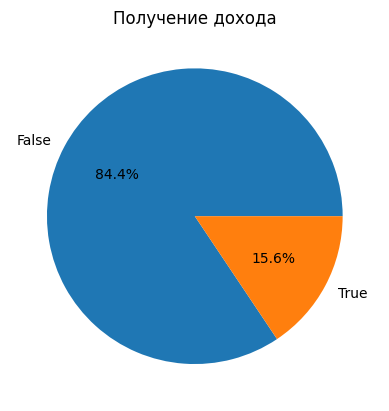

In [13]:
plt.pie(gr['counts'], labels=gr['counts'].index.to_list(), autopct='%1.1f%%')
plt.title("Получение дохода")
plt.show()

In [ ]:
df.loc[df['Browser'] == 1,'Browser_s'] = 'Firefox'
df.loc[df['Browser'] == 2,'Browser_s'] = 'Google Chrome'
df.loc[df['Browser'] == 3,'Browser_s'] = 'Microsoft Edge'
df.loc[df['Browser'] == 4,'Browser_s'] = 'Apple Safari'
df.loc[df['Browser'] == 5,'Browser_s'] = 'Opera'
df.loc[df['Browser'] == 6,'Browser_s'] = 'Brave'
df.loc[df['Browser'] == 7,'Browser_s'] = 'UCBrowser'
df.loc[df['Browser'] == 8,'Browser_s'] = 'DuckDuckgo'
df.loc[df['Browser'] == 9,'Browser_s'] = 'Chromium'
df.loc[df['Browser'] == 10,'Browser_s'] = 'Epic'
df.loc[df['Browser'] == 11,'Browser_s'] = 'Internet Explorer'
df.loc[df['Browser'] == 12,'Browser_s'] = 'Tor Browser'
df.loc[df['Browser'] == 13,'Browser_s'] = 'Maxthon'

df.loc[df['OperatingSystems'] == 1,'OperatingSystems_s'] = 'IOS'
df.loc[df['OperatingSystems'] == 2,'OperatingSystems_s'] = 'Android Mobile'
df.loc[df['OperatingSystems'] == 3,'OperatingSystems_s'] = 'Windows'
df.loc[df['OperatingSystems'] == 4,'OperatingSystems_s'] = 'Linux'
df.loc[df['OperatingSystems'] == 5,'OperatingSystems_s'] = 'MS-DOS'
df.loc[df['OperatingSystems'] == 6,'OperatingSystems_s'] = 'Fedora'
df.loc[df['OperatingSystems'] == 7,'OperatingSystems_s'] = 'Ubuntu'
df.loc[df['OperatingSystems'] == 8,'OperatingSystems_s'] ='Solaris'

df.loc[df['Region'] == 1,'Region_s'] = 'China'
df.loc[df['Region'] == 2,'Region_s'] = 'Indonesia'
df.loc[df['Region'] == 3,'Region_s'] = 'India'
df.loc[df['Region'] == 4,'Region_s'] = 'United States'
df.loc[df['Region'] == 5,'Region_s'] = 'Brazil'
df.loc[df['Region'] == 6,'Region_s'] = 'Nigeria'
df.loc[df['Region'] == 7,'Region_s'] = 'Japan'
df.loc[df['Region'] == 8,'Region_s'] = 'Russia'
df.loc[df['Region'] == 9,'Region_s'] = 'Bangladesh'

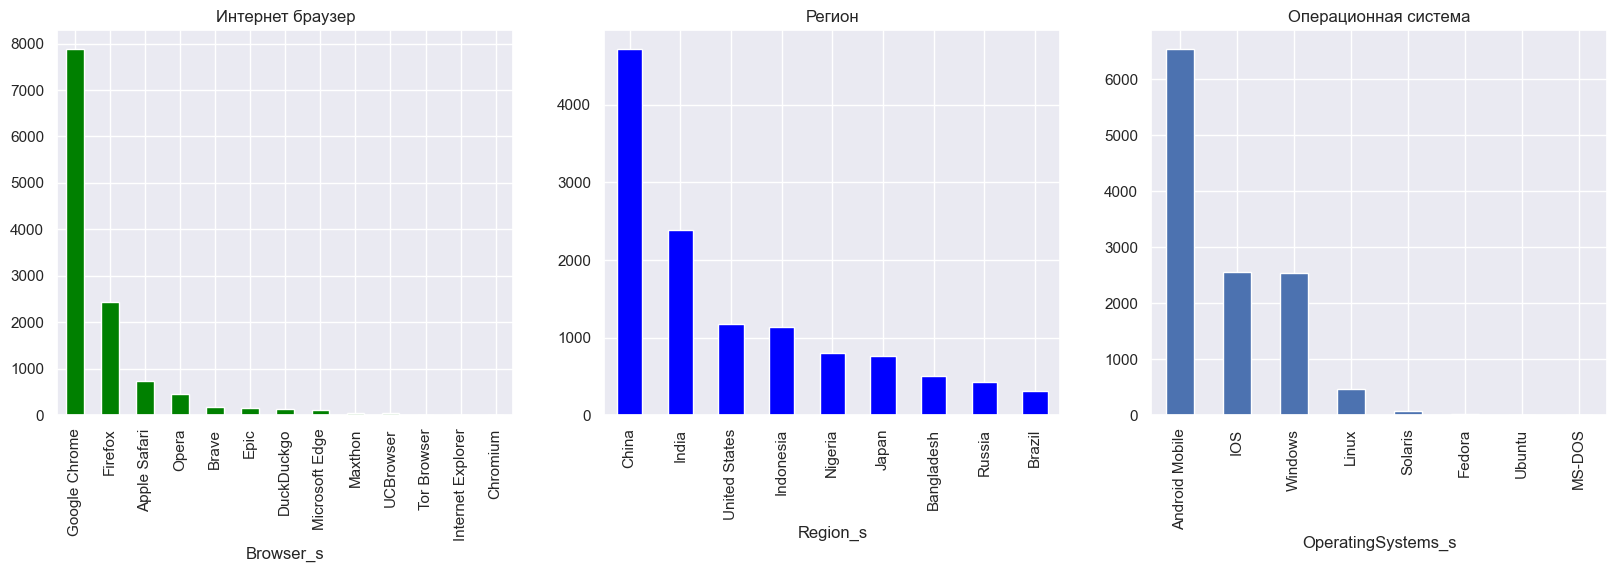

In [15]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(20, 5))
plt.axis('off')

plt.figure(1)
plt.subplot(131)
df['Browser_s'].value_counts().plot.bar(title="Интернет браузер", color='green')
plt.subplot(132)
df['Region_s'].value_counts().plot.bar(title="Регион", color='blue')
plt.subplot(133)
df['OperatingSystems_s'].value_counts().plot.bar(title="Операционная система")
plt.show()

In [17]:
series_revenue = df["Region_s"].value_counts()
series_revenue_pct = series_revenue/df["Region_s"].value_counts().sum()
series_format_percent = "{:.1%}".format
series_format_count = "{:,d}".format

display(pd.DataFrame({"counts": series_revenue.apply(series_format_count), \
                      "percent": series_revenue_pct.apply(series_format_percent)}))

,counts,percent
Region_s,,
China,"4,722",38.6%
India,"2,381",19.5%
United States,"1,173",9.6%
Indonesia,"1,131",9.3%
Nigeria,801,6.6%
Japan,758,6.2%
Bangladesh,505,4.1%
Russia,432,3.5%
Brazil,318,2.6%


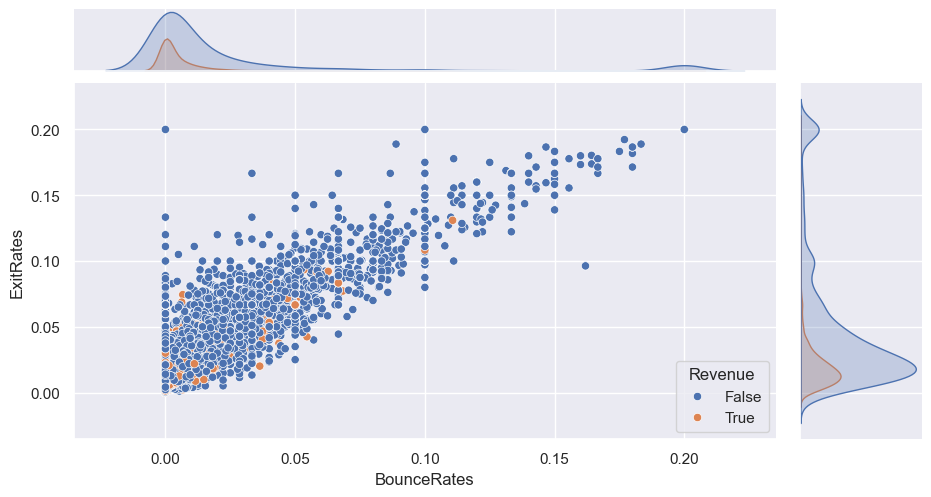

In [19]:
g = sns.jointplot(data=df, x="BounceRates", y="ExitRates", hue="Revenue")
g.figure.set_size_inches(10, 5)
plt.show()

** Вывод

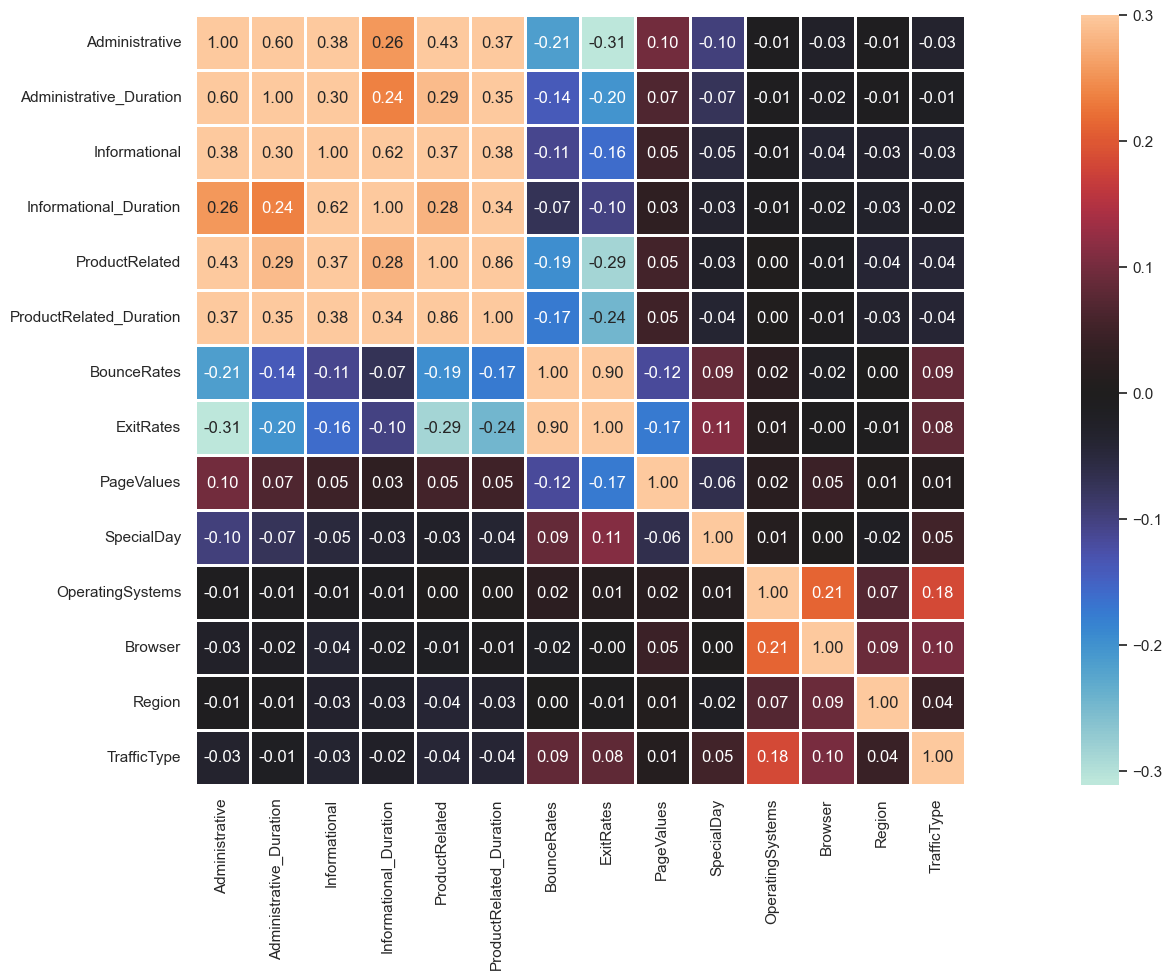

In [ ]:
plt.figure(figsize=(30, 10))
corr = df.select_dtypes(np.number).corr()
g = sns.heatmap(corr, vmax=.3, center=0, square=True, linewidths=1, annot=True, fmt='.2f')
plt.show()

** Корреляция

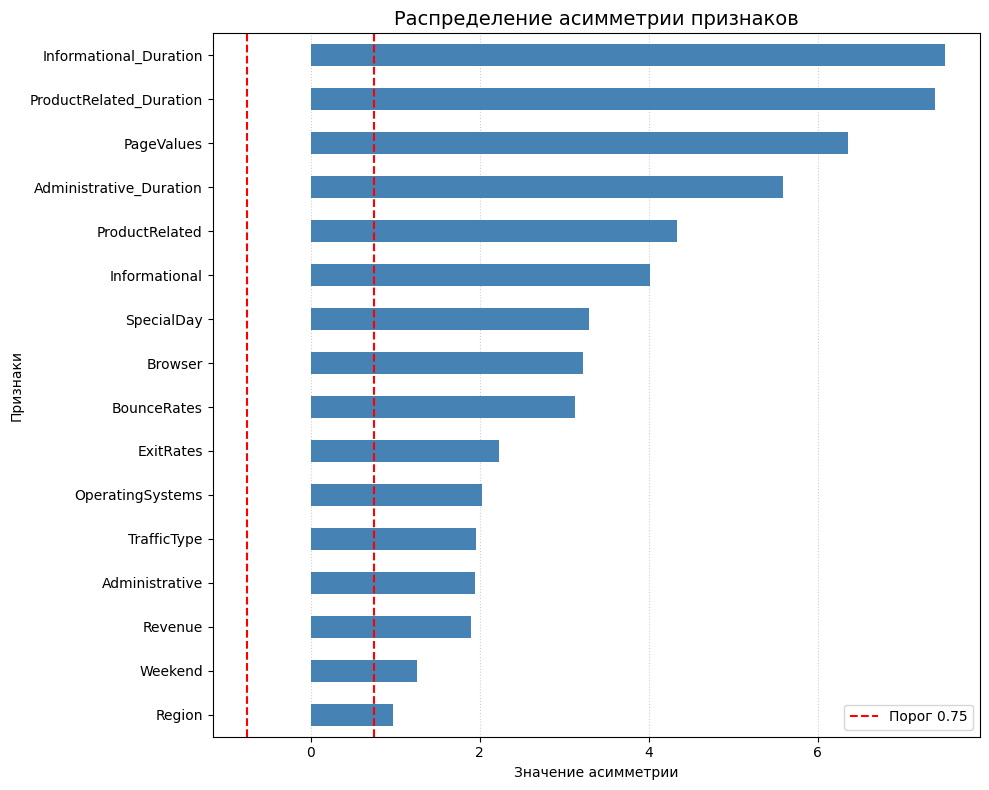

In [10]:
skewed_feats = df.skew(numeric_only=True).sort_values(ascending=True)
skewed_feats_result = skewed_feats[lambda x: x.abs() > 0.75]

plt.figure(figsize=(10, 8))
skewed_feats_result.plot(kind='barh', color='steelblue', zorder=2)

plt.axvline(x=0.75, color='red', linestyle='--', linewidth=1.5, label='Порог 0.75')
plt.axvline(x=-0.75, color='red', linestyle='--', linewidth=1.5)

plt.title('Распределение асимметрии признаков', fontsize=14)
plt.xlabel('Значение асимметрии')
plt.ylabel('Признаки')
plt.legend()
plt.grid(axis='x', linestyle=':', alpha=0.6, zorder=1)

plt.tight_layout()
plt.show()

Вывод: Распределение асимметрии признаков правосторонее по всем показателем > 0.75
* Skew ≈ 0 — симметричное распределение.
* Skew > 0 — распределение положительно (правостороннее), «хвост» данных уходит вправо, в сторону больших значений.
* Skew < 0 — распределение отрицательно (левостороннее), «хвост» данных уходит влево, в сторону маленьких значений.

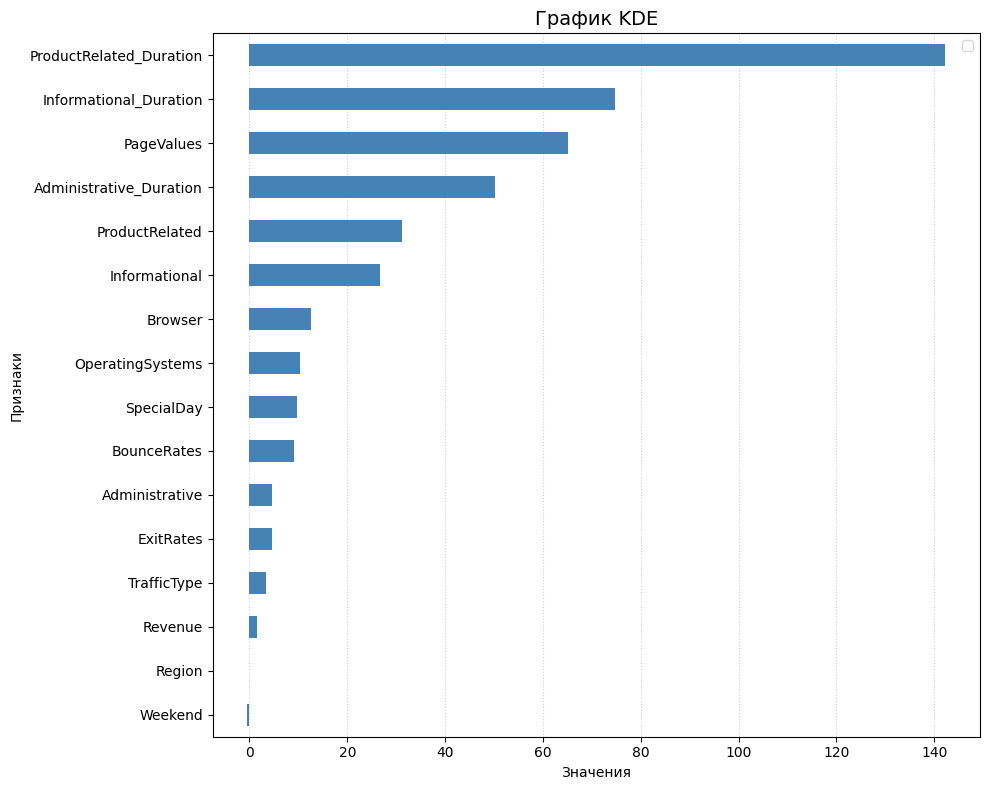

In [ ]:
plt.figure(figsize=(10, 8))
df.kurtosis(numeric_only=True).sort_values(ascending=True).plot(kind='barh', color='steelblue', zorder=2)
plt.title('График KDE', fontsize=14)
plt.xlabel('Значения')
plt.ylabel('Признаки')
plt.legend()
plt.grid(axis='x', linestyle=':', alpha=0.6, zorder=1)

plt.tight_layout()
plt.show()

Вывод: Насколько сильно распределение влияет на экстремальные значения (выбросы)
* Если куртозис больше 0, распределение leptokurtic — хвосты толще, чем у нормального, что указывает на кластер выбросов.
* Если куртозис меньше 0, распределение platykurtic — хвосты тоньше, чем у нормального, что означает отрицательный избыток выбросов.
* Если куртозис равен 0, распределение mesokurtic — хвосты такие же, как у нормального распределения.

In [22]:
df_copy = df.copy()

In [ ]:
print(df.iloc[:,[5,6]]).columns

x = df.iloc[:,[5,6]].values
x.shape
print(x)

[[0.0000000e+00 2.0000000e-01]
 [6.4000000e+01 0.0000000e+00]
 [0.0000000e+00 2.0000000e-01]
 ...
 [1.8425000e+02 8.3333333e-02]
 [3.4600000e+02 0.0000000e+00]
 [2.1250000e+01 0.0000000e+00]]
